# QAOA for Maximum Cut
## Part II: C4 Complete Analysis — Gate-by-Gate Derivation

**Physics 565/656 · Spring 2026 · Sehong Park**

This notebook dissects QAOA on the 4-cycle $C_4$ in complete detail: explicit Hamiltonian, gate decomposition, statevector tracking, landscape, and optimal state at $p=1,2,3$.

**Contents**
1. C4 structure and cost Hamiltonian  
2. Gate decomposition of $U_C(\gamma)$ — CNOT–RZ–CNOT  
3. Statevector tracking (p=1)  
4. Optimal parameters and probability distribution  
5. Scaling to p=2,3  
6. Circuit depth and resource analysis

---
## 1. C4 Structure

$C_4$: four vertices $\{0,1,2,3\}$, four edges $E=\{(0,1),(1,2),(2,3),(3,0)\}$.

**Key property:** $C_4$ is bipartite (partition $\{0,2\}$ vs $\{1,3\}$), so $C_{\max}=|E|=4$.

$$H_C = \frac{I-Z_0Z_1}{2}+\frac{I-Z_1Z_2}{2}+\frac{I-Z_2Z_3}{2}+\frac{I-Z_3Z_0}{2}$$

The two ground states of $-H_C$ (max-cut states) are $|0101\rangle$ and $|1010\rangle$.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize

n = 4
edges_c4 = [(0,1),(1,2),(2,3),(3,0)]

def build_diag(edges, n):
    d = np.zeros(2**n)
    for x in range(2**n):
        bits = [(x>>i)&1 for i in range(n)]
        d[x] = sum((bits[i]!=bits[j]) for i,j in edges)
    return d

diag = build_diag(edges_c4, n)
print('Bitstring -> cut value mapping:')
for z in range(2**n):
    bits = ''.join(str((z>>k)&1) for k in range(n))
    marker = ' <-- max cut' if diag[z]==4 else ''
    print(f'  |{bits}> -> {diag[z]:.0f}{marker}')

Bitstring -> cut value mapping:
  |0000> -> 0
  |1000> -> 2
  |0100> -> 2
  |1100> -> 2
  |0010> -> 2
  |1010> -> 4 <-- max cut
  |0110> -> 2
  |1110> -> 2
  |0001> -> 2
  |1001> -> 2
  |0101> -> 4 <-- max cut
  |1101> -> 2
  |0011> -> 2
  |1011> -> 2
  |0111> -> 2
  |1111> -> 0


---
## 2. Gate Decomposition of $U_C(\gamma)$

$$U_C(\gamma)=e^{-i\gamma H_C}=\prod_{(i,j)\in E}e^{-i\gamma\frac{I-Z_iZ_j}{2}}$$

Each factor (up to global phase $e^{-i\gamma/2}$):

$$e^{i\frac{\gamma}{2}Z_iZ_j}=\mathrm{CNOT}_{i\to j}\cdot R_Z(-\gamma)_j\cdot\mathrm{CNOT}_{i\to j}$$

**Why?** $\mathrm{CNOT}_{i\to j}$ maps $Z_j\mapsto Z_iZ_j$ (CNOT conjugates $Z$ on the target by adding the control). Therefore the $R_Z(-\gamma)_j=e^{i\gamma Z_j/2}$ becomes $e^{i\gamma Z_iZ_j/2}$ in the CNOT-sandwiched form.

Explicitly for edge $(0,1)$:

$$\mathrm{CNOT}_{01}\cdot R_Z(-\gamma)_1\cdot\mathrm{CNOT}_{01}:\begin{cases}|00\rangle\to e^{+i\gamma/2}|00\rangle\\|01\rangle\to e^{-i\gamma/2}|01\rangle\\|10\rangle\to e^{-i\gamma/2}|10\rangle\\|11\rangle\to e^{+i\gamma/2}|11\rangle\end{cases}$$

The phase $e^{+i\gamma/2}$ on same-spin pairs and $e^{-i\gamma/2}$ on different-spin pairs — exactly $e^{i\gamma Z_iZ_j/2}$.

In [2]:
# Verify CNOT-Rz-CNOT identity numerically
import numpy as np
from scipy.linalg import expm

I2   = np.eye(2, dtype=complex)
Z    = np.array([[1,0],[0,-1]], dtype=complex)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

def Rz(theta):
    return np.array([[np.exp(-1j*theta/2), 0],
                     [0, np.exp( 1j*theta/2)]], dtype=complex)

gamma = 0.7

# Circuit sequence: CNOT · (I ⊗ Rz(-gamma)) · CNOT
gate_circuit = CNOT @ np.kron(I2, Rz(-gamma)) @ CNOT

# Direct matrix exponential (scipy — exact, no Taylor truncation)
ZZ = np.kron(Z, Z)
gate_direct = expm(1j * gamma/2 * ZZ)

# Direct element-wise comparison (ratio check causes 0/0 at zero off-diagonal entries)
max_diff = np.max(np.abs(gate_circuit - gate_direct))
print('CNOT–Rz(–gamma)–CNOT  vs  exp(i*gamma/2 * ZZ):')
print(f'  Max |circuit - direct|: {max_diff:.2e}')
print('  -> Decomposition is exact (matrices are identical)\n')

# Action on computational basis
print('Phase applied per basis state:')
for z in range(4):
    ket = np.zeros(4, dtype=complex); ket[z] = 1
    phase = np.angle((gate_circuit @ ket)[z])
    q0, q1 = (z>>1)&1, z&1
    s0, s1 = 1-2*q0, 1-2*q1
    expected = gamma/2 * s0 * s1
    print(f'  |{q0}{q1}>  cut={int(q0!=q1)}  '
          f'phase={phase:+.4f}  expected {expected:+.4f}')

CNOT–Rz(–gamma)–CNOT  vs  exp(i*gamma/2 * ZZ):
  Max |circuit - direct|: 0.00e+00
  -> Decomposition is exact (matrices are identical)

Phase applied per basis state:
  |00>  cut=0  phase=+0.3500  expected +0.3500
  |01>  cut=1  phase=-0.3500  expected -0.3500
  |10>  cut=1  phase=-0.3500  expected -0.3500
  |11>  cut=0  phase=+0.3500  expected +0.3500


---
## 2.1 Qiskit Circuit Implementation

We now implement the QAOA circuit for $C_4$ at $p=1$ directly in Qiskit. Each edge $(i,j)$ contributes a CNOT–$R_Z(-\gamma)$–CNOT block to $U_C(\gamma)$, and each qubit gets an $R_X(2\beta)$ gate in $U_B(\beta)$.

C4 QAOA circuit (p=1):
  Depth:    15
  CX gates: 8
  Rz gates: 4
  Rx gates: 4



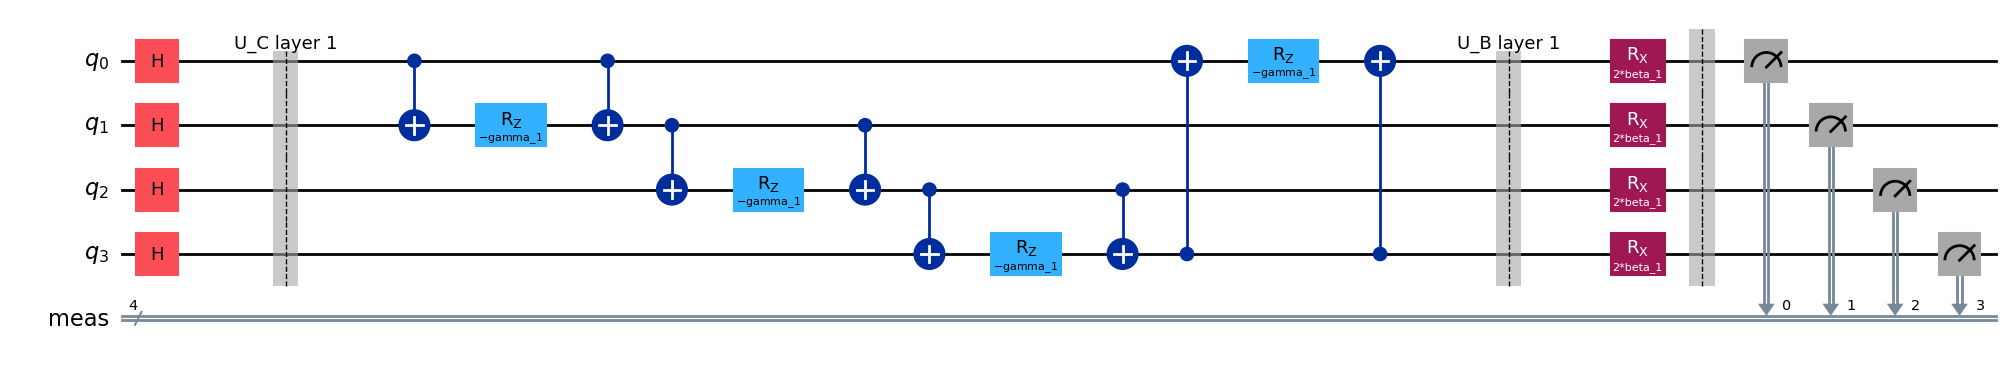

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

def build_qaoa_circuit_c4(p, gamma_vals=None, beta_vals=None):
    """
    QAOA circuit for C4 MaxCut.
    If gamma_vals/beta_vals are None, uses symbolic Parameters (for drawing).
    Otherwise binds the given numerical values.
    """
    n = 4
    edges = [(0,1),(1,2),(2,3),(3,0)]
    qc = QuantumCircuit(n)

    # Initial state: |+>^n
    qc.h(range(n))

    for layer in range(p):
        if gamma_vals is None:
            gamma = Parameter(f'gamma_{layer+1}')
        else:
            gamma = gamma_vals[layer]

        if beta_vals is None:
            beta = Parameter(f'beta_{layer+1}')
        else:
            beta = beta_vals[layer]

        # U_C(gamma): one CNOT-Rz-CNOT block per edge
        qc.barrier(label=f'U_C layer {layer+1}')
        for (i, j) in edges:
            qc.cx(i, j)          # CNOT control=i, target=j
            qc.rz(-gamma, j)     # Rz(-gamma) on target
            qc.cx(i, j)          # CNOT again

        # U_B(beta): Rx(2*beta) on every qubit
        qc.barrier(label=f'U_B layer {layer+1}')
        for k in range(n):
            qc.rx(2*beta, k)

    qc.measure_all()
    return qc

# ── Draw the symbolic p=1 circuit ────────────────────────────────
qc_sym = build_qaoa_circuit_c4(p=1)
print('C4 QAOA circuit (p=1):')
print(f'  Depth:    {qc_sym.depth()}')
print(f'  CX gates: {qc_sym.count_ops().get("cx", 0)}')
print(f'  Rz gates: {qc_sym.count_ops().get("rz", 0)}')
print(f'  Rx gates: {qc_sym.count_ops().get("rx", 0)}')
print()
qc_sym.draw('mpl', fold=-1, style='iqp')

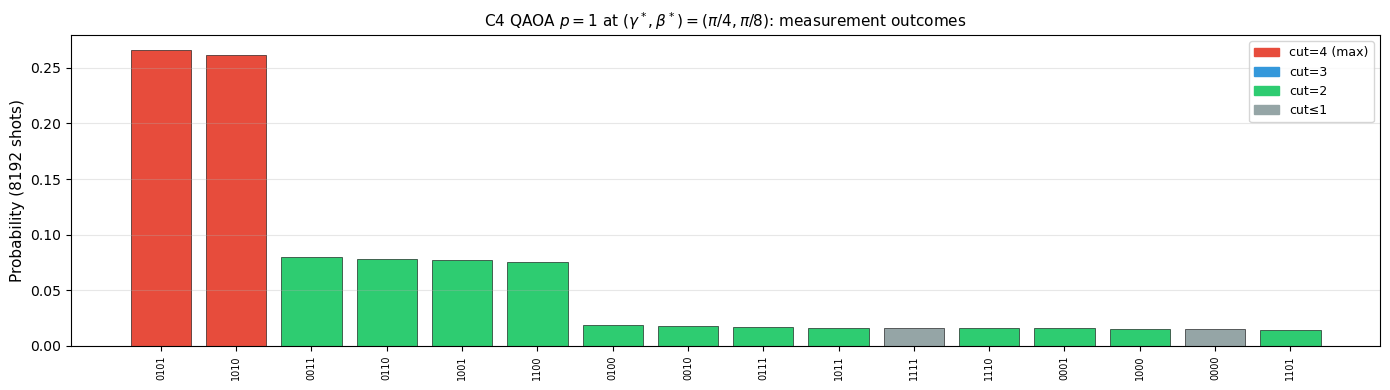

P(max cut) from circuit: 0.5278
Dominant states: [('0101', 2181), ('1010', 2143), ('0011', 652), ('0110', 637)]


In [4]:
import numpy as np
from qiskit_aer import AerSimulator

# ── Bind optimal parameters (gamma*=pi/4, beta*=pi/8) and simulate
gamma_opt = np.pi/4
beta_opt  = np.pi/8

qc_bound = build_qaoa_circuit_c4(p=1,
                                  gamma_vals=[gamma_opt],
                                  beta_vals=[beta_opt])

sim = AerSimulator()
job = sim.run(qc_bound, shots=8192)
counts = job.result().get_counts()

# Sort by count
sorted_counts = sorted(counts.items(), key=lambda x: -x[1])

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

bitstrings = [b for b,_ in sorted_counts]
freqs      = [c/8192 for _,c in sorted_counts]

# Colour: red = max cut, blue = cut 3, green = cut 2, grey = cut 0/1
def cut_val(bs, edges=[(0,1),(1,2),(2,3),(3,0)]):
    bits = [int(b) for b in bs]
    return sum(bits[i]!=bits[j] for i,j in edges)

bar_colors = []
for bs in bitstrings:
    cv = cut_val(bs[::-1])  # Qiskit reverses bit order
    if cv == 4:   bar_colors.append('#E74C3C')
    elif cv == 3: bar_colors.append('#3498DB')
    elif cv == 2: bar_colors.append('#2ECC71')
    else:         bar_colors.append('#95A5A6')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(bitstrings)), freqs, color=bar_colors, edgecolor='black', lw=0.4)
ax.set_xticks(range(len(bitstrings)))
ax.set_xticklabels(bitstrings, rotation=90, fontsize=7)
ax.set_ylabel('Probability (8192 shots)', fontsize=11)
ax.set_title(r'C4 QAOA $p=1$ at $(\gamma^*,\beta^*)=(\pi/4,\pi/8)$: measurement outcomes',
             fontsize=11)
legend_els = [
    mpatches.Patch(color='#E74C3C', label='cut=4 (max)'),
    mpatches.Patch(color='#3498DB', label='cut=3'),
    mpatches.Patch(color='#2ECC71', label='cut=2'),
    mpatches.Patch(color='#95A5A6', label='cut≤1'),
]
ax.legend(handles=legend_els, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Summary
p_maxcut = sum(c for b,c in counts.items() if cut_val(b[::-1])==4) / 8192
print(f'P(max cut) from circuit: {p_maxcut:.4f}')
print(f'Dominant states: {sorted_counts[:4]}')

---
## 3. Statevector Tracking (p=1)

We track $|\psi\rangle$ through each operation explicitly.

**Step 0:** $|\psi_0\rangle = H^{\otimes 4}|0000\rangle = \frac{1}{4}\sum_{z\in\{0,1\}^4}|z\rangle$

**Step 1:** Apply $U_C(\gamma)$: multiply each amplitude by $e^{-i\gamma C(z)}$

$$U_C(\gamma)|\psi_0\rangle = \frac{1}{4}\sum_z e^{-i\gamma C(z)}|z\rangle$$

**Step 2:** Apply $U_B(\beta)=\bigotimes R_X(2\beta)$: mixes amplitudes across Hamming-1 neighbours

**Energy:** $F_1 = \langle\psi_1|H_C|\psi_1\rangle$

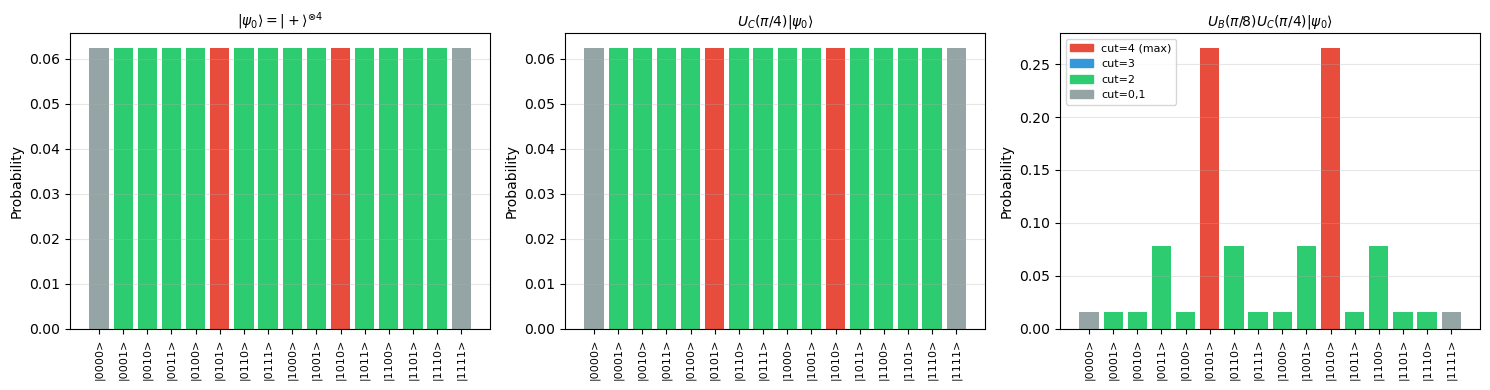

Expected energy: F1 = 3.0000
Approx ratio:    0.7500
P(max cut):      0.5312  (states |0101> and |1010>)


In [5]:
# Step-by-step statevector for C4 at optimal (gamma*=pi/4, beta*=pi/8)
gamma_opt = np.pi/4
beta_opt  = np.pi/8

# Step 0: uniform superposition
psi0 = np.ones(2**n)/np.sqrt(2**n) + 0j

# Step 1: UC(gamma)
psi1 = np.exp(-1j*gamma_opt*diag)*psi0

# Step 2: UB(beta)
def apply_UB(psi, beta, n):
    c,s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi2 = psi.reshape([2]*n)
        psi2 = np.moveaxis(psi2,q,0).reshape(2,-1)
        psi2 = np.array([c*psi2[0]-1j*s*psi2[1], -1j*s*psi2[0]+c*psi2[1]])
        psi2 = psi2.reshape([2]*n)
        psi = np.moveaxis(psi2,0,q).reshape(-1)
    return psi

psi2 = apply_UB(psi1, beta_opt, n)

# Plot amplitudes at each step
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = [f'|{z:04b}>' for z in range(2**n)]
cut_colors = ['#E74C3C' if diag[z]==4 else '#3498DB' if diag[z]==3
              else '#2ECC71' if diag[z]==2 else '#95A5A6' for z in range(2**n)]

for ax, psi, title in [
    (axes[0], psi0, r'$|\psi_0\rangle = |+\rangle^{\otimes 4}$'),
    (axes[1], psi1, r'$U_C(\pi/4)|\psi_0\rangle$'),
    (axes[2], psi2, r'$U_B(\pi/8)U_C(\pi/4)|\psi_0\rangle$')
]:
    probs = np.abs(psi)**2
    ax.bar(range(2**n), probs, color=cut_colors)
    ax.set_xticks(range(2**n))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_ylabel('Probability')
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(color='#E74C3C', label='cut=4 (max)'),
    Patch(color='#3498DB', label='cut=3'),
    Patch(color='#2ECC71', label='cut=2'),
    Patch(color='#95A5A6', label='cut=0,1'),
]
axes[2].legend(handles=legend_els, fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

# Energy
E_final = float(np.real(np.dot(psi2.conj(), diag*psi2)))
p_maxcut = sum(np.abs(psi2[z])**2 for z in range(2**n) if diag[z]==4)
print(f'Expected energy: F1 = {E_final:.4f}')
print(f'Approx ratio:    {E_final/4:.4f}')
print(f'P(max cut):      {p_maxcut:.4f}  (states |0101> and |1010>)')

---
## 4. Optimal Parameters and Probability Distribution

For $C_4$ at $p=1$, the analytic optima are $\gamma^*=\pi/4$ and $\beta^*=\pi/8$.

**Why $\gamma^*=\pi/4$?** The cost unitary writes amplitudes as $e^{-i\gamma C(z)}$. At $\gamma=\pi/4$, max-cut states ($C=4$) acquire phase $e^{-i\pi}=-1$, while zero-cut states ($C=0$) stay at $+1$. This maximises the amplitude contrast before the mixer.

**Why $\beta^*=\pi/8$?** The mixer $R_X(2\beta)=R_X(\pi/4)$ partially rotates within each qubit's Bloch sphere. This angle is the sweet spot between over-rotation (too much mixing) and under-rotation (no mixing).

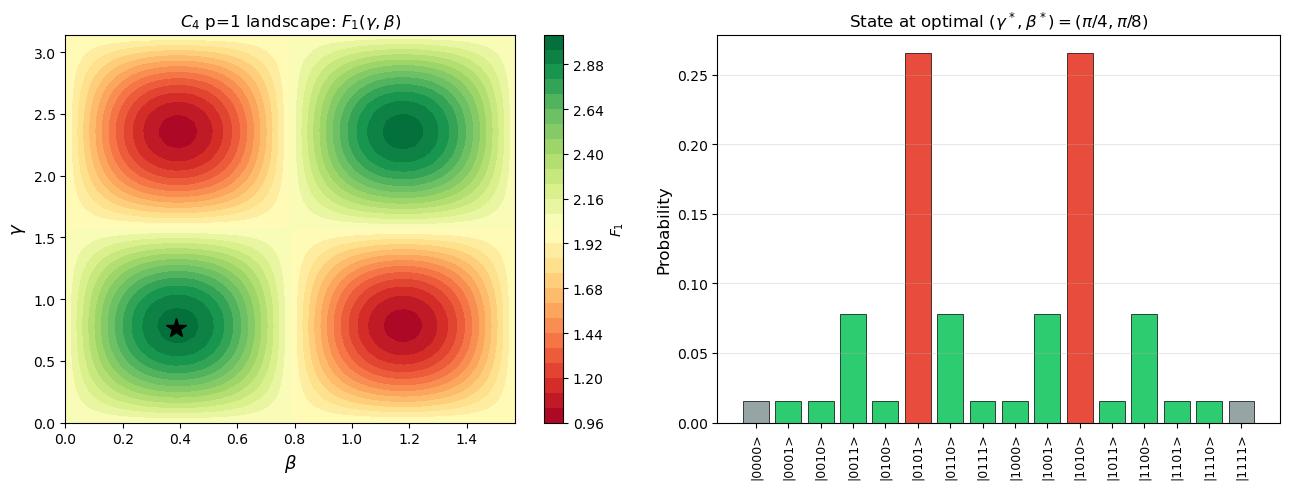

Probabilities at optimal:
  |0000>  C=0  P=0.0156
  |0001>  C=2  P=0.0156
  |0010>  C=2  P=0.0156
  |0011>  C=2  P=0.0781
  |0100>  C=2  P=0.0156
  |0101>  C=4  P=0.2656
  |0110>  C=2  P=0.0781
  |0111>  C=2  P=0.0156
  |1000>  C=2  P=0.0156
  |1001>  C=2  P=0.0781
  |1010>  C=4  P=0.2656
  |1011>  C=2  P=0.0156
  |1100>  C=2  P=0.0781
  |1101>  C=2  P=0.0156
  |1110>  C=2  P=0.0156
  |1111>  C=0  P=0.0156


In [6]:
# Landscape and optimal distribution
Ng = 50
gs = np.linspace(0, np.pi, Ng)
bs = np.linspace(0, np.pi/2, Ng)

def qaoa_energy(gamma, beta):
    psi = np.exp(-1j*gamma*diag) * (np.ones(2**n)/np.sqrt(2**n) + 0j)
    return float(np.real(np.dot(apply_UB(psi,beta,n).conj(), diag*apply_UB(psi,beta,n))))

F = np.array([[qaoa_energy(g,b) for b in bs] for g in gs])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].contourf(bs, gs, F, levels=30, cmap='RdYlGn')
plt.colorbar(im, ax=axes[0], label=r'$F_1$')
opt_idx = np.unravel_index(np.argmax(F), F.shape)
axes[0].plot(bs[opt_idx[1]], gs[opt_idx[0]], 'k*', ms=15)
axes[0].set_xlabel(r'$\beta$', fontsize=13)
axes[0].set_ylabel(r'$\gamma$', fontsize=13)
axes[0].set_title(r'$C_4$ p=1 landscape: $F_1(\gamma,\beta)$')

# Probability at optimal
psi_opt = apply_UB(np.exp(-1j*(np.pi/4)*diag)*(np.ones(2**n)/np.sqrt(2**n)+0j), np.pi/8, n)
probs_opt = np.abs(psi_opt)**2
colors_bar = ['#E74C3C' if diag[z]==4 else '#3498DB' if diag[z]==3
              else '#2ECC71' if diag[z]==2 else '#95A5A6' for z in range(2**n)]
axes[1].bar(range(2**n), probs_opt, color=colors_bar, edgecolor='black', lw=0.5)
axes[1].set_xticks(range(2**n))
axes[1].set_xticklabels([f'|{z:04b}>' for z in range(2**n)], rotation=90, fontsize=9)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title(r'State at optimal $(\gamma^*,\beta^*)=(\pi/4,\pi/8)$')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Probabilities at optimal:')
for z in range(2**n):
    if probs_opt[z] > 0.01:
        print(f'  |{z:04b}>  C={diag[z]:.0f}  P={probs_opt[z]:.4f}')

---
## 5. Scaling to p=2,3

Increasing $p$ adds more expressive power. The optimisation landscape for $p>1$ is non-convex, and the number of parameters grows as $2p$.

p=1: F=3.0000  ratio=0.7500  P(max cut)=0.5312
p=2: F=4.0000  ratio=1.0000  P(max cut)=1.0000
p=3: F=4.0000  ratio=1.0000  P(max cut)=1.0000


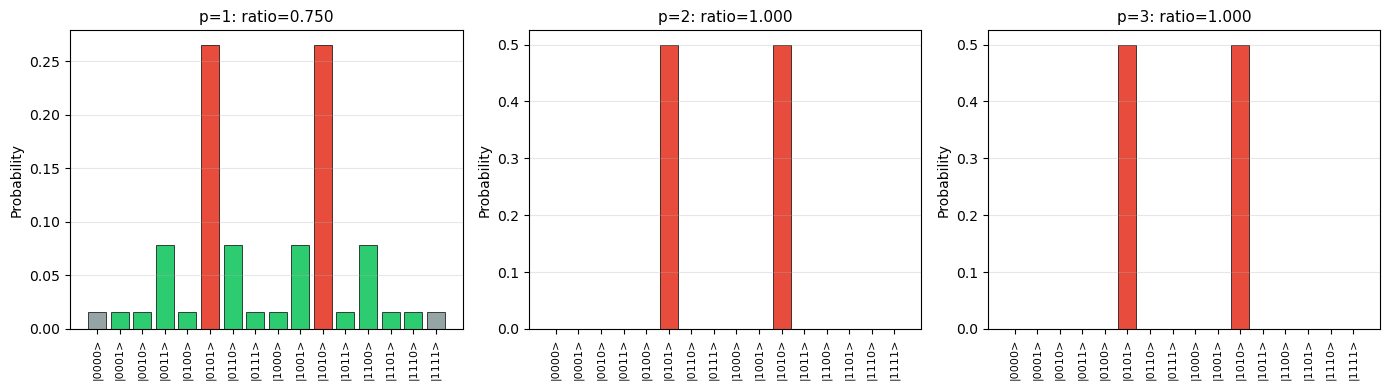

In [7]:
def qaoa_eval(params, edges, n, p):
    gamma = params[:p]; beta = params[p:]
    psi = np.ones(2**n)/np.sqrt(2**n) + 0j
    diag_ = build_diag(edges, n)
    for layer in range(p):
        psi = np.exp(-1j*gamma[layer]*diag_)*psi
        psi = apply_UB(psi, beta[layer], n)
    return -float(np.real(np.dot(psi.conj(), diag_*psi))), psi

results_p = {}
for p in [1,2,3]:
    best_val, best_params = -np.inf, None
    np.random.seed(42+p)
    for _ in range(20):  # multi-start
        x0 = np.random.uniform(0, np.pi, 2*p)
        res = minimize(lambda x: qaoa_eval(x, edges_c4, n, p)[0], x0,
                       method='COBYLA', options={'maxiter':500,'rhobeg':0.3})
        if -res.fun > best_val:
            best_val = -res.fun
            best_params = res.x
    _, psi_best = qaoa_eval(best_params, edges_c4, n, p)
    results_p[p] = {'F': best_val, 'ratio': best_val/4, 'psi': psi_best}
    print(f'p={p}: F={best_val:.4f}  ratio={best_val/4:.4f}  '
          f'P(max cut)={sum(np.abs(psi_best[z])**2 for z in range(2**n) if diag[z]==4):.4f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, p in zip(axes, [1,2,3]):
    psi_p = results_p[p]['psi']
    probs_p = np.abs(psi_p)**2
    colors_p = ['#E74C3C' if diag[z]==4 else '#3498DB' if diag[z]==3
                else '#2ECC71' if diag[z]==2 else '#95A5A6' for z in range(2**n)]
    ax.bar(range(2**n), probs_p, color=colors_p, edgecolor='black', lw=0.5)
    ax.set_xticks(range(2**n))
    ax.set_xticklabels([f'|{z:04b}>' for z in range(2**n)], rotation=90, fontsize=8)
    ax.set_title(f'p={p}: ratio={results_p[p]["ratio"]:.3f}', fontsize=11)
    ax.set_ylabel('Probability')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6. Circuit Depth and Resource Analysis

| $p$ | Parameters | CX gates | $R_Z$ gates | $R_X$ gates | Total 2-qubit gates |
|-----|-----------|---------|------------|------------|--------------------|
| 1   | 2         | 8       | 4          | 4          | 8                  |
| 2   | 4         | 16      | 8          | 8          | 16                 |
| 3   | 6         | 24      | 12         | 12         | 24                 |

**General formula** for $C_4$ (4 edges, 4 qubits):
- CX count: $2p|E| = 8p$
- Circuit depth (serial): $O(p|E|) = O(4p)$ (all edges serialised)
- Circuit depth (parallel): $O(p \cdot \text{coloring}) = O(2p)$ (edges can be parallelised by graph coloring)

$C_4$ has chromatic index 2 (two edge colors suffice), so all 4 edges can be implemented in 2 parallel groups per layer.

---
## References

- Farhi, Goldstone, Gutmann. arXiv:1411.4028 (2014).
- Zhou et al. 'Quantum approximate optimization algorithm: Performance, mechanism, and implementation.' *PRX* 10, 021067 (2020).